In [1]:
# Re-import libraries after code reset
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

In [2]:
# Environment setup
grid_size = (4, 4)
terminal_states = [(0, 0), (3, 3)]
rewards = -0.1 * np.ones(grid_size)
rewards[0, 0] = 1.0
rewards[3, 3] = 1.0
gamma = 0.9
alpha = 0.1
episodes = 5000
actions = ['U', 'D', 'L', 'R']
action_to_delta = {'U': (-1, 0), 'D': (1, 0), 'L': (0, -1), 'R': (0, 1)}

In [3]:
# Helper: Get next state
def get_next_state(state, action):
    delta = action_to_delta[action]
    next_state = (state[0] + delta[0], state[1] + delta[1])
    if 0 <= next_state[0] < grid_size[0] and 0 <= next_state[1] < grid_size[1]:
        return next_state
    return state

# Epsilon-greedy policy for Q-learning
def choose_action(state, Q, epsilon=0.1):
    if random.random() < epsilon:
        return random.choice(actions)
    i, j = state
    return actions[np.argmax(Q[i, j])]

# TD(0) for State-Value Function V(s)
def td_value_learning():
    V = np.zeros(grid_size)
    snapshots = []

    for ep in range(1, episodes + 1):
        state = (random.randint(0, 3), random.randint(0, 3))
        while state in terminal_states:
            state = (random.randint(0, 3), random.randint(0, 3))

        done = False
        while not done:
            action = random.choice(actions)
            next_state = get_next_state(state, action)
            reward = rewards[next_state]

            if state not in terminal_states:
                V[state] += alpha * (reward + gamma * V[next_state] - V[state])

            if next_state in terminal_states:
                done = True
            state = next_state

        if ep % 500 == 0:
            snapshots.append(V.copy())
    return V, snapshots

# TD for Q-value: Q-learning (off-policy)
def td_q_learning():
    Q = np.zeros(grid_size + (len(actions),))
    snapshots = []

    for ep in range(1, episodes + 1):
        state = (random.randint(0, 3), random.randint(0, 3))
        while state in terminal_states:
            state = (random.randint(0, 3), random.randint(0, 3))

        done = False
        while not done:
            action = choose_action(state, Q)
            next_state = get_next_state(state, action)
            reward = rewards[next_state]
            a_idx = actions.index(action)

            if state not in terminal_states:
                Q[state][a_idx] += alpha * (
                    reward + gamma * np.max(Q[next_state]) - Q[state][a_idx]
                )

            if next_state in terminal_states:
                done = True
            state = next_state

        if ep % 500 == 0:
            snapshots.append(np.max(Q, axis=-1).copy())
    return Q, snapshots

In [4]:
# Plotting
def plot_value_function(V, title):
    fig, ax = plt.subplots(figsize=(6, 6))
    for i in range(grid_size[0]):
        for j in range(grid_size[1]):
            ax.add_patch(patches.Rectangle((j, grid_size[0] - 1 - i), 1, 1, fill=False))
            ax.text(j + 0.5, grid_size[0] - 1 - i + 0.4, f"{V[i, j]:.2f}", ha='center', fontsize=10)
    ax.set_xlim(0, grid_size[1])
    ax.set_ylim(0, grid_size[0])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_snapshots(snapshots, title_prefix):
    for i, V in enumerate(snapshots):
        fig, ax = plt.subplots()
        c = ax.imshow(V, cmap='coolwarm', origin='upper')
        ax.set_title(f"{title_prefix} - Episode {(i + 1) * 500}")
        fig.colorbar(c)
        plt.show()

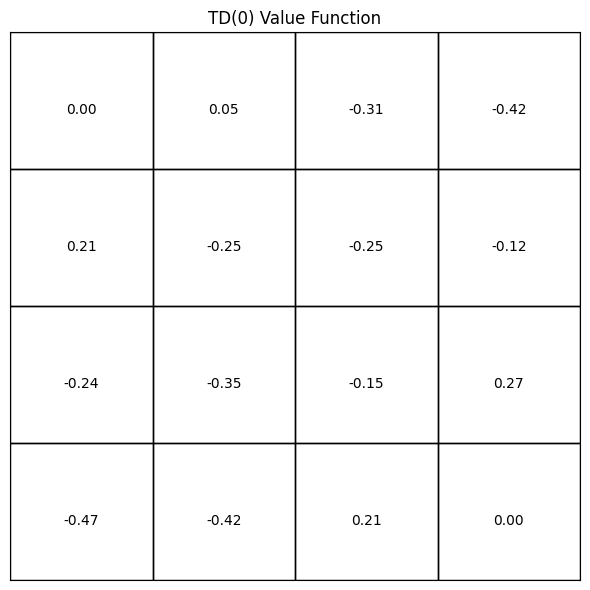

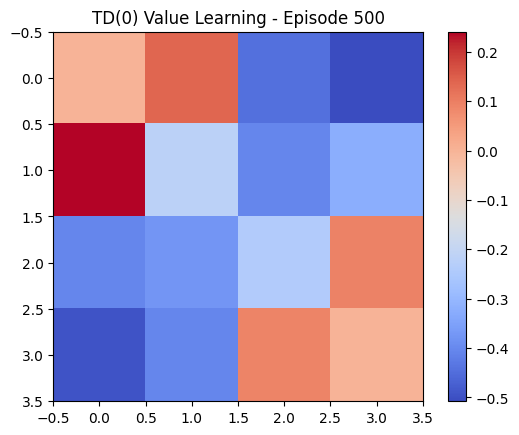

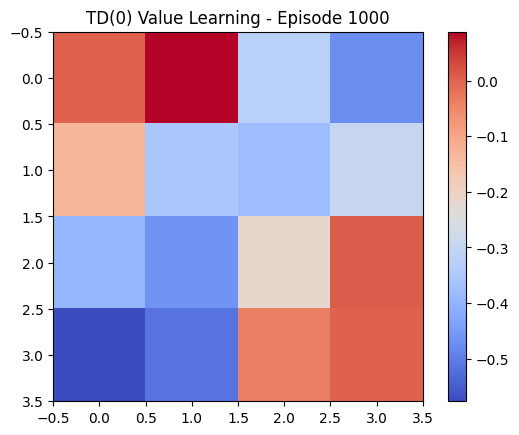

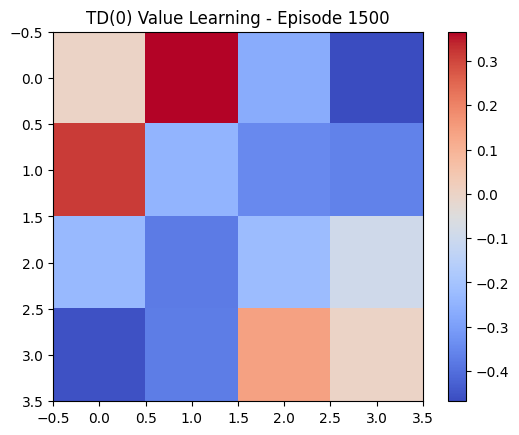

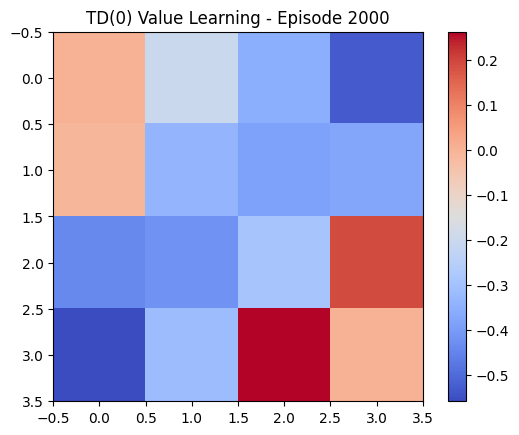

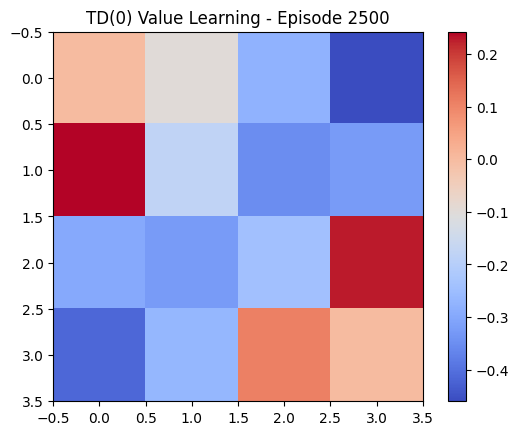

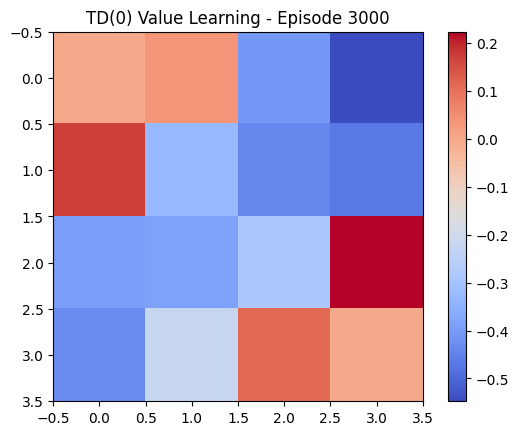

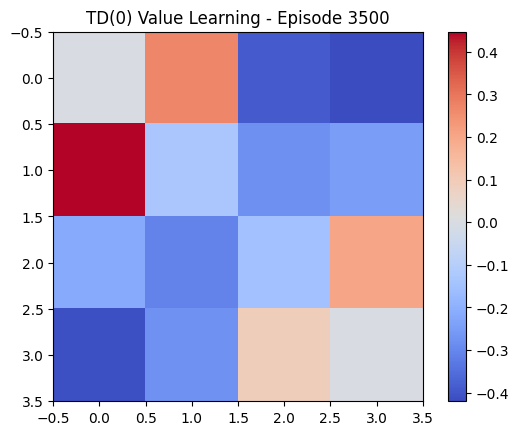

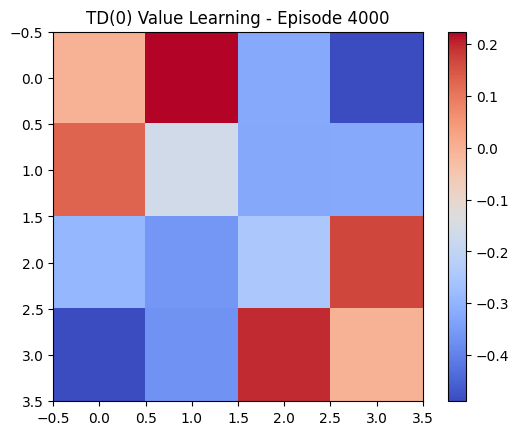

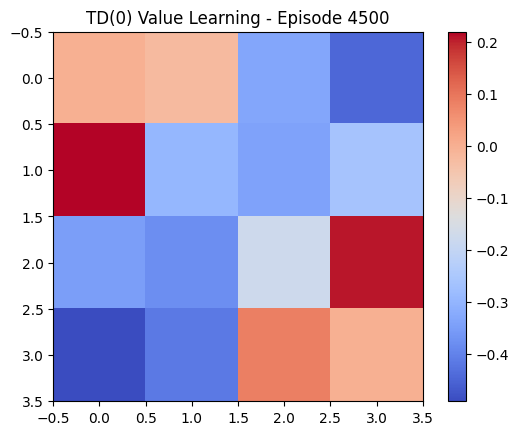

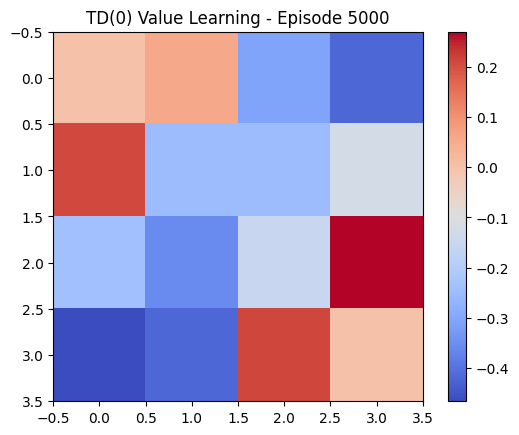

In [5]:
# Run and visualize TD learning
V_td, V_td_snapshots = td_value_learning()
plot_value_function(V_td, "TD(0) Value Function")
plot_snapshots(V_td_snapshots, "TD(0) Value Learning")

# Q_td, Q_td_snapshots = td_q_learning()
# plot_snapshots(Q_td_snapshots, "TD Q-Learning (Q-Value)")